In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [171]:
df = pd.read_csv("insurance.csv")
print(df.head())



   Id   age gender   bmi  bloodpressure diabetic  children smoker     region  \
0   1 39.00   male 23.20             91      Yes         0     No  southeast   
1   2 24.00   male 30.10             87       No         0     No  southeast   
2   3   NaN   male 33.30             82      Yes         0     No  southeast   
3   4   NaN   male 33.70             80       No         0     No  northwest   
4   5   NaN   male 34.10            100       No         0     No  northwest   

    claim  
0 1121.87  
1 1131.51  
2 1135.94  
3 1136.40  
4 1137.01  


In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [173]:
pd.set_option("display.float_format","{:.2f}".format)

In [174]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


In [175]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [176]:
df.duplicated().sum()

0

In [177]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [178]:
df.dropna(inplace=True)

In [179]:
df.shape

(1332, 10)

In [180]:
df.isnull().sum()

Id               0
age              0
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           0
claim            0
dtype: int64

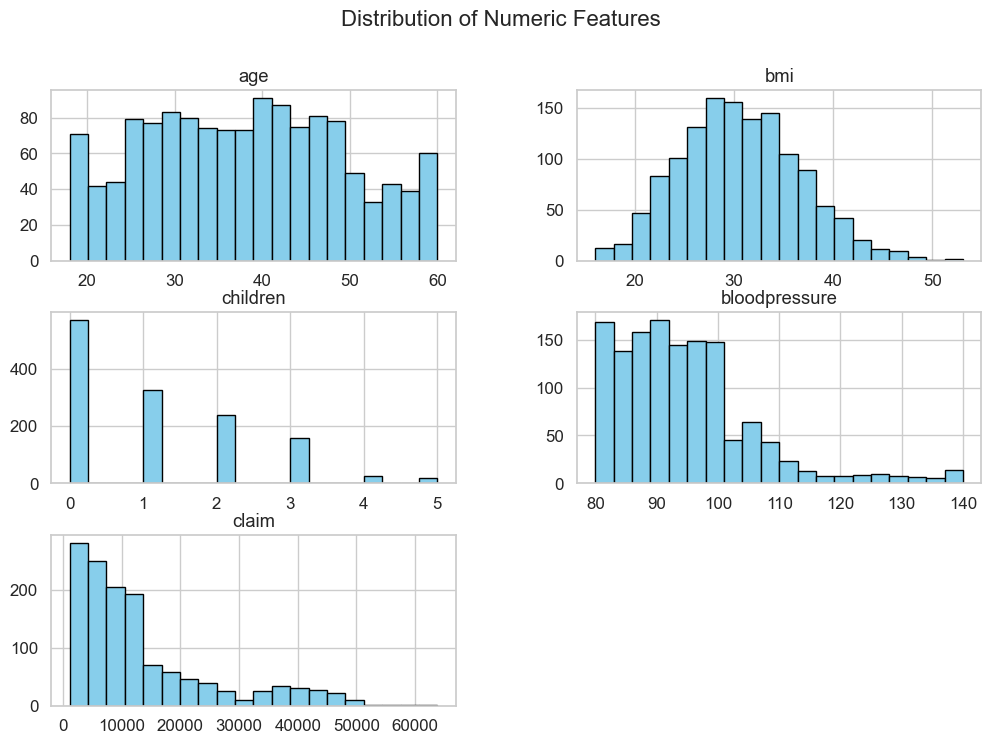

In [181]:
numeric_cols=["age","bmi","children","bloodpressure","claim"]
df[numeric_cols].hist(bins=20, figsize=(12,8),color="skyblue", edgecolor="black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

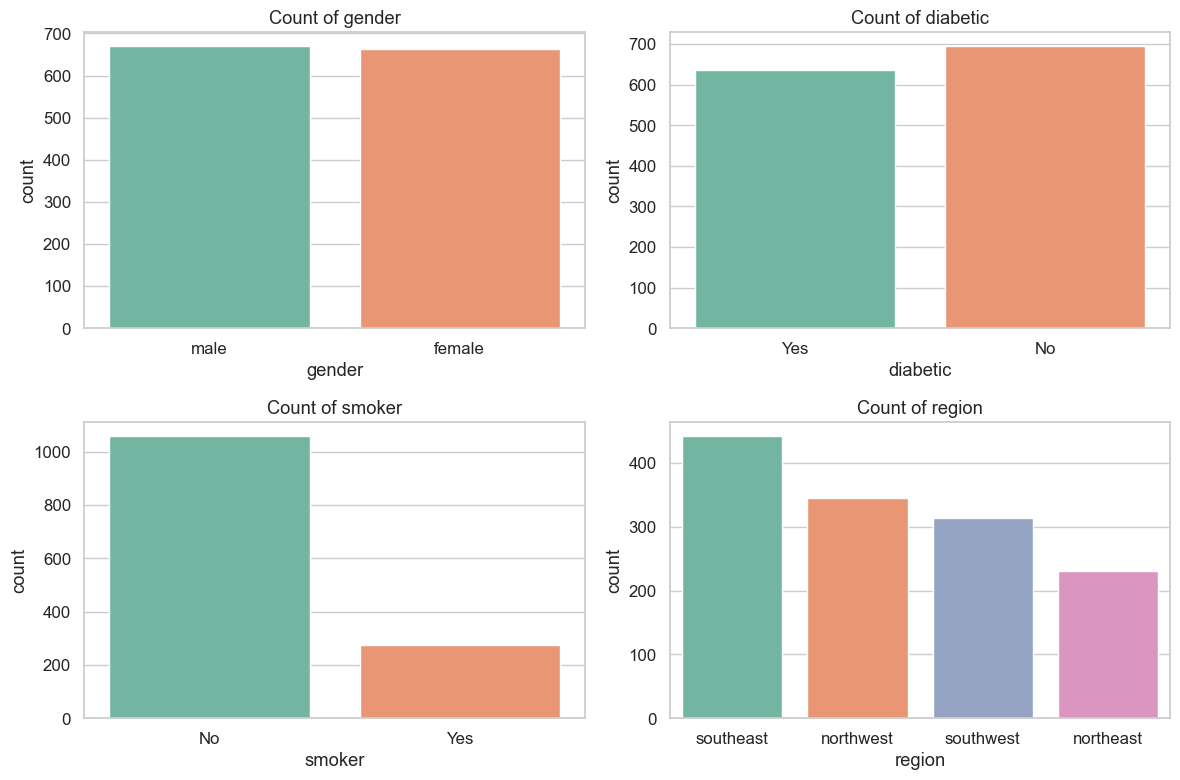

In [182]:
cat_cols=["gender","diabetic","smoker","region"]
plt.figure(figsize=(12,8))
for i, col in enumerate(cat_cols,1):
    plt.subplot(2, 2, i)
    sns.countplot(data = df, x = col,palette="Set2")
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()

In [183]:
df.groupby(["gender","smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

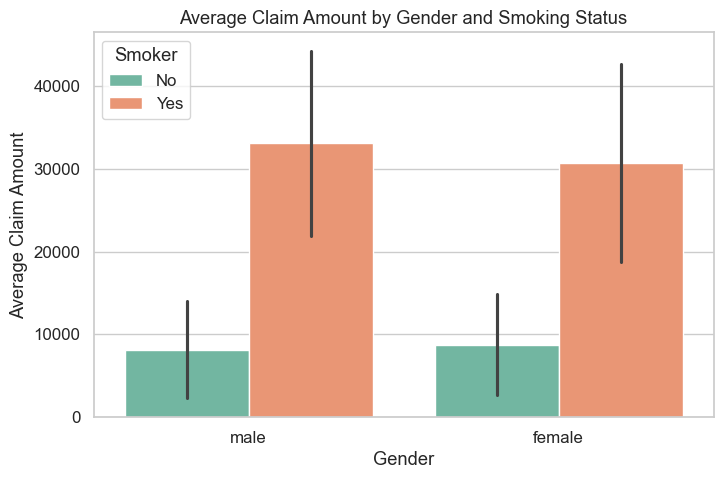

In [184]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", palette="Set2",estimator="mean",errorbar='sd')
plt.title("Average Claim Amount by Gender and Smoking Status")
plt.ylabel("Average Claim Amount")  
plt.xlabel("Gender")
plt.legend(title="Smoker")          
plt.show()

In [185]:
pivot_region_diabetic=df.groupby(["region","diabetic"])["claim"].mean().round(2).unstack()
pivot_region_diabetic


diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


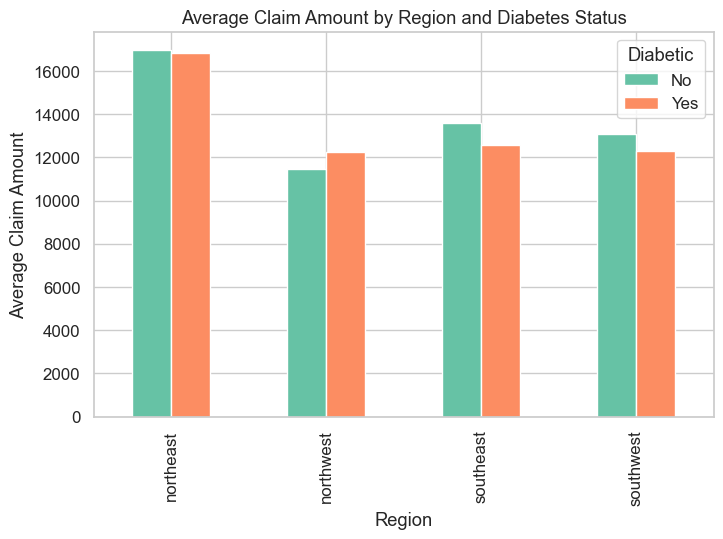

In [186]:
pivot_region_diabetic.plot(kind="bar", figsize=(8,5),)
plt.title("Average Claim Amount by Region and Diabetes Status")
plt.ylabel("Average Claim Amount")  
plt.xlabel("Region")
plt.legend(title="Diabetic", labels=["No", "Yes"])
plt.show()


In [187]:
pivot_table=pd.pivot_table(df,values="claim", index="region", columns="smoker", aggfunc="mean").round(2)
pivot_table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [188]:
pivot_table=pd.pivot_table(df, values="claim", index="children", columns="diabetic", aggfunc="mean").round(2)
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


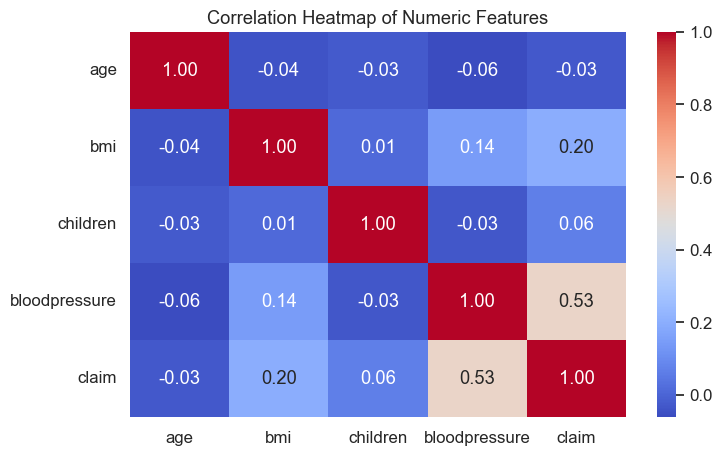

In [189]:
plt.figure(figsize=(8,5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [190]:
df["age_group"]=pd.cut(df["age"], bins=[0, 18, 30, 45, 60, 100], labels=["0-18", "19-35", "36-50", "51-65", "66+"])


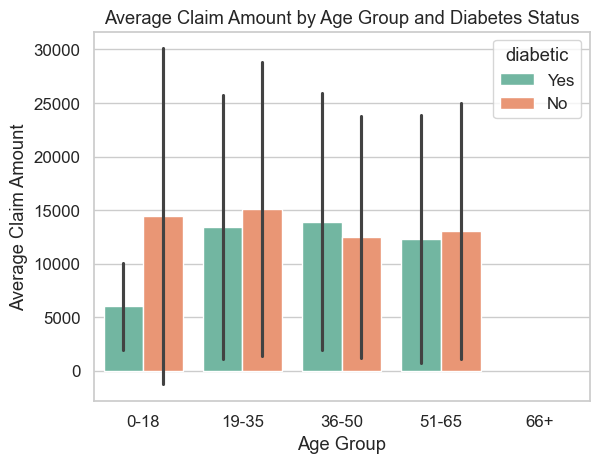

In [191]:
sns.barplot(data=df, x="age_group", y="claim", hue="diabetic", palette="Set2", estimator="mean", errorbar='sd')
plt.title("Average Claim Amount by Age Group and Diabetes Status")
plt.ylabel("Average Claim Amount")      
plt.xlabel("Age Group")
plt.show()

In [192]:
df["bmi_category"]=pd.cut(df["bmi"], bins=[0, 18.5, 24.9, 29.9, 100], labels=["Underweight", "Normal", "Overweight", "Obese"])


In [193]:
df["bmi_category"].value_counts()

bmi_category
Obese          702
Overweight     387
Normal         222
Underweight     21
Name: count, dtype: int64

In [194]:
import warnings
warnings.filterwarnings("ignore")

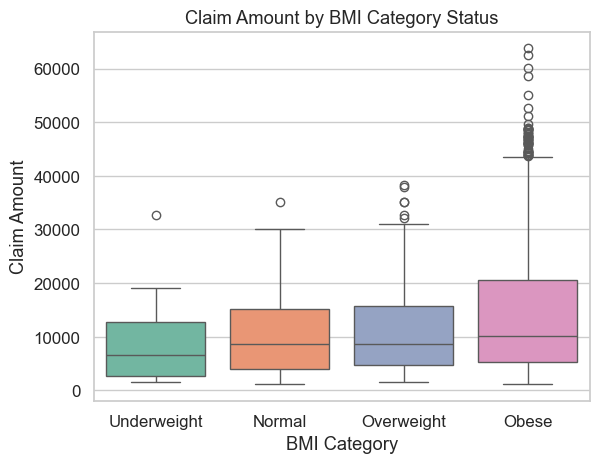

In [195]:
sns.boxplot(data = df, x="bmi_category", y="claim", palette="Set2")
plt.title("Claim Amount by BMI Category Status")
plt.ylabel("Claim Amount")
plt.xlabel("BMI Category")
plt.show()


In [196]:
region_stats =df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="yes").mean()*100),
    mean_claim = ("claim", "mean")
).reset_index()
region_stats

,region,smoker_rate,mean_claim
0,northeast,0.00,16889.04
1,northwest,0.00,11794.22
2,southeast,0.00,13085.50
3,southwest,0.00,12723.13


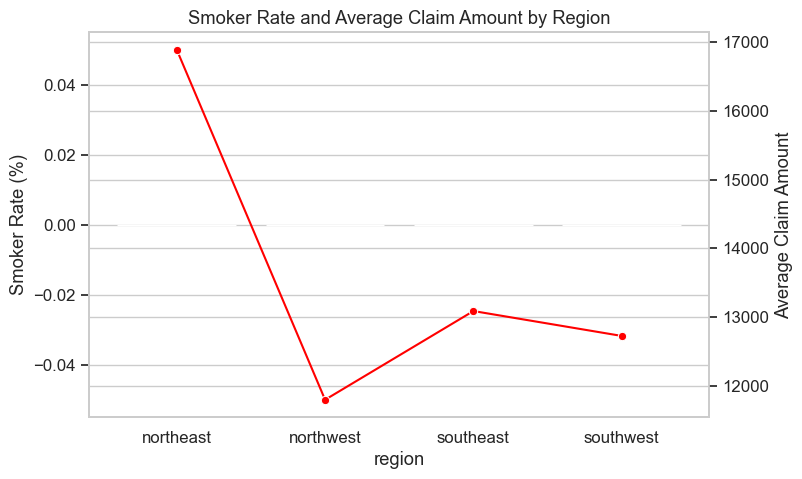

In [197]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data=region_stats, x="region", y="smoker_rate", ax=ax1, palette="Set2")
ax2 = ax1.twinx()
sns.lineplot(data=region_stats, x="region", y="mean_claim", ax=ax2, color="red", marker="o")
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim Amount")
plt.title("Smoker Rate and Average Claim Amount by Region")
plt.show()

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [199]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [200]:
X = df[["age","gender","bmi","bloodpressure","diabetic","children","smoker"]]
y = df["claim"]

In [201]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [202]:
cat_cols=["gender","diabetic","smoker"]
label_encoders={}   
for col in cat_cols:
    le = LabelEncoder()
    X[col]=le.fit_transform(X[col])
    label_encoders[col]=le

# Save ONLY the individual encoders (not the entire dict)
joblib.dump(label_encoders["gender"], "label_encoders_gender.pkl")
joblib.dump(label_encoders["diabetic"], "label_encoders_diabetic.pkl")
joblib.dump(label_encoders["smoker"], "label_encoders_smoker.pkl")

# Print what each encoder knows
print("Gender classes:", label_encoders["gender"].classes_)
print("Diabetic classes:", label_encoders["diabetic"].classes_)
print("Smoker classes:", label_encoders["smoker"].classes_)

Gender classes: ['female' 'male']
Diabetic classes: ['No' 'Yes']
Smoker classes: ['No' 'Yes']


In [203]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [204]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [205]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [206]:
num_cols=["age","bmi","bloodpressure","children"]
scaler=StandardScaler()


In [207]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [208]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [209]:
print(X_train.shape,y_train.shape)


(1065, 7) (1065,)


In [210]:
print(X_test.shape,y_test.shape)


(267, 7) (267,)


In [211]:
%pip install xgboost

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR 
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import xgboost
from xgboost import XGBRegressor





Note: you may need to restart the kernel to use updated packages.


In [212]:
def evaluate_model(model,X_train, X_test, y_test,y_train):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae=np.sqrt(mean_squared_error(y_test, y_pred))
    rmse=np.sqrt(mean_squared_error(y_test, y_pred))
    return{"R2": r2, "MAE": mae,"RMSE":rmse}


In [213]:
result={}

In [214]:
lr = LinearRegression()
lr.fit(X_train, y_train)
result["Linear Regression"]=evaluate_model(lr,X_train, X_test, y_test,y_train)
print("LinearRegression trained")


best_poly_model=None
best_poly_score=-np.inf
best_degree=None
best_poly_features=None

for degree in [2,3]:
    poly_features = PolynomialFeatures(degree=degree)
    X_train_poly = poly_features.fit_transform(X_train)
    X_test_poly = poly_features.transform(X_test)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    
    score = r2_score(y_test, poly_model.predict(X_test_poly))
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = poly_model
        best_degree = degree
        best_poly_features = poly_features

result[f"polynomial Regression (deg = {best_degree})"] = evaluate_model(best_poly_model, best_poly_features.fit_transform(X_train), best_poly_features.transform(X_test), y_test,y_train)

print("Polynomial Regression trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],    
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(estimator=rf, param_grid=rf_params, cv=5, n_jobs=-1, verbose=2,scoring="r2")
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

result["Random Forest"]=evaluate_model(best_rf,X_train, X_test, y_test,y_train)
print("Random Forest trained", rf_grid.best_params_)

svr=SVR()

svr_params={
    "kernel": ["rbf","poly", "linear"],
    "C":[1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3]

}

svr_grid=GridSearchCV(estimator=svr, param_grid=svr_params, cv=3, n_jobs=-1, verbose=2,scoring="r2")
svr_grid.fit(X_train, y_train)
best_svr=svr_grid.best_estimator_

result["SVR"]=evaluate_model(best_svr,X_train, X_test, y_test,y_train)

print("SVR trained", svr_grid.best_params_)


XGB_params={
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.1],
    "max_depth":[3,5],
    "subsample":[0.8,1],
}
xgb_grid=GridSearchCV(estimator=XGBRegressor(), param_grid=XGB_params, cv=3, n_jobs=-1, verbose=0,scoring="r2")
xgb_grid.fit(X_train, y_train)
best_xgb=xgb_grid.best_estimator_

result["XGBoost"]=evaluate_model(best_xgb,X_train, X_test, y_test,y_train)
print("XGBoost trained", xgb_grid.best_params_)



LinearRegression trained
Polynomial Regression trained
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Random Forest trained {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 3 folds for each of 54 candidates, totalling 162 fits
SVR trained {'C': 50, 'degree': 2, 'epsilon': 0.5, 'kernel': 'linear'}
XGBoost trained {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [215]:
result

{'Linear Regression': {'R2': 0.7186402865210724,
  'MAE': 6368.137982018985,
  'RMSE': 6368.137982018985},
 'polynomial Regression (deg = 2)': {'R2': 0.7757814325424965,
  'MAE': 5684.827554251736,
  'RMSE': 5684.827554251736},
 'Random Forest': {'R2': 0.8183294457736865,
  'MAE': 5117.098524651943,
  'RMSE': 5117.098524651943},
 'SVR': {'R2': 0.49799294655626736,
  'MAE': 8506.216223009234,
  'RMSE': 8506.216223009234},
 'XGBoost': {'R2': 0.8270382329943683,
  'MAE': 4992.9425057445405,
  'RMSE': 4992.9425057445405}}

In [216]:
result_df=pd.DataFrame(result).T.sort_values(by="R2", ascending=False)
result_df

,R2,MAE,RMSE
XGBoost,0.83,4992.94,4992.94
Random Forest,0.82,5117.10,5117.10
polynomial Regression (deg = 2),0.78,5684.83,5684.83
Linear Regression,0.72,6368.14,6368.14
SVR,0.50,8506.22,8506.22


In [217]:
models = {
    "Linear Regression": lr,
    f"Polynomial Regression (deg = {best_degree})": best_poly_model,
    "Random Forest": best_rf,
    "SVR": best_svr,
    "XGBoost": best_xgb
}

In [218]:
best_r2=result_df["R2"].max()
best_r2

0.8270382329943683

In [219]:
top_model=result_df[result_df["R2"]==best_r2]
top_model

,R2,MAE,RMSE
XGBoost,0.83,4992.94,4992.94


In [220]:
best_model=models[top_model.index[0]]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [221]:
joblib.dump(best_model, "best_model.pkl")
print(f"Best model saved as best_model.pkl: {top_model.index[0]}")


Best model saved as best_model.pkl: XGBoost
